In [2]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root

Welcome to JupyROOT 6.26/16


In [3]:
#We can pull in our merged and unmerged hit data. The neutrino vertices array is common to both files.
data_unmerged = np.load('../hitwise_detector_sim_0002459.npz')
data_merged = np.load('../python/test_0002459_merged.npz')
neutrino_vertices = data_unmerged['first']
hit_array_unmerged = data_unmerged['second']
hit_array_merged = data_merged['first']
print(np.shape(hit_array_unmerged))
print(np.shape(hit_array_merged))

(252256, 7)
(107479, 8)


In [4]:
#Some useful sorting functions
def SortByTime(array):
    sorted_array = array[np.argsort(array[:,5])]
    return(sorted_array)

def SortByNN(array):
    sorted_array = array[np.argsort(array[:,0])]
    return(sorted_array)

sorted_hits_merged = SortByTime(hit_array_merged)
sorted_hits_unmerged = SortByTime(hit_array_unmerged)

In [5]:
#A useful data structure that can serve as a test of energy efficiency. This array stores total hits and total PEs for neutrino numbers

# | neutrino number | total PEs | total hits |

#Patched from initial development as there was an extra row and a kinda useless conditional

#Creates this array using unmerged PEs
neutrino_PE_array_unmerged = np.zeros((5978, 3))
for i in range(5978):
    PEs = 0.
    sub_array = sorted_hits_unmerged[sorted_hits_unmerged[:, 0] == i] #grabs the rows where neutrino number matches the desired one
    n_hits = 0
    for hit in sub_array:
        n_hits += 1 
        PEs += hit[6]
    neutrino_PE_array_unmerged[i][0] = i
    neutrino_PE_array_unmerged[i][1] = PEs
    neutrino_PE_array_unmerged[i][2] = n_hits

#print(neutrino_PE_array_unmerged)

#Creates this array using unmerged PEs
neutrino_PE_array_merged = np.zeros((5978, 3))
for i in range(5978):
    PEs = 0.
    sub_array = sorted_hits_merged[sorted_hits_merged[:, 0] == i]
    n_hits = 0
    for hit in sub_array:
        n_hits += 1
        PEs += hit[6]
    neutrino_PE_array_merged[i][0] = i
    neutrino_PE_array_merged[i][1] = PEs
    neutrino_PE_array_merged[i][2] = n_hits

#print(neutrino_PE_array_merged)

#do a quick check of PE balance. 
if (np.sum(neutrino_PE_array_merged[:,1]) != np.sum(neutrino_PE_array_unmerged[:,1])):
    print("Warning, merged total PE != unmerged total PE")

In [6]:
#A time slicer based on the principles of the dune-tms slicer. takes thresholds and a hits array. I think this is working as intended. 
#This function will return a list of lists of arrays. lol
#Patched to stop adding the hit after energy drops below threshold

def SimpleTimeSlicer(hits, initial_threshold_energy=50, drop_threshold_energy=40):
    sorted_hits = SortByTime(hits)
    events = []  # This object stores the final "events" or slices that are grouped by the algorithm
    window_duration_ns = 19

    current_window_hits = collections.deque()
    current_window_energy_sum = 0.0

    in_accumulation_phase = False
    current_event_hits = []  # Stores hit info for our event that is accumulating

    for hit_row in sorted_hits:  # Iterate through each full hit row
        hit_time = hit_row[5]    # Time is at index 5
        hit_energy = hit_row[6]  # Energy is at index 6

        # Add the current full hit row to the window
        current_window_hits.append(hit_row)  # Store the entire row
        current_window_energy_sum += hit_energy  # Add the hit energy to our current window

        # Remove hits that are outside the current window, basically sliding the deque forward
        # The window is defined by (current_hit_time - window_duration_ns, current_hit_time]
        while current_window_hits and current_window_hits[0][5] <= hit_time - window_duration_ns:
            # This loop removes all hits from the front of the window that are outside 
            # the time range (older than hit_time - window_duration_ns)
            oldest_hit_row = current_window_hits.popleft()  # Get the full oldest row
            oldest_hit_energy = oldest_hit_row[6]  # Access energy from the row
            current_window_energy_sum -= oldest_hit_energy

        # Handle accumulation logic
        if not in_accumulation_phase:
            # Not in accumulation, if we pass the threshold we should start
            if current_window_energy_sum >= initial_threshold_energy:
                in_accumulation_phase = True  # Here we activate accumulation mode - begin a slice.
                # When we *start* accumulation, initialize `current_event_hits` with
                # all hits currently within the *valid* window (i.e., those in `current_window_hits`).
                # We need to make a copy here (`list(...)`) because `current_window_hits`
                # will continue to change as the window slides.
                # This making a copy rather than grabbing it every time the hit slides 
                # was the reason we encountered duplicates in previous versions
                current_event_hits = list(current_window_hits)
        else:
            # We ARE currently in an accumulation phase
            # Check if the energy in the *current window* has dropped below the threshold,
            # BEFORE adding the most recent hit to the accumulating event
            if current_window_energy_sum < drop_threshold_energy:
                # If indeed we have dropped below threshold, go ahead and 
                events.append(current_event_hits)
                in_accumulation_phase = False  # Turning off accumulation mode
                current_event_hits = []  # Reset for the next event - dumping the current event's hit list
            else:
                # Still above threshold, so include the current hit
                current_event_hits.append(hit_row)

    # After iterating through all hits, check if we were still in an accumulation phase.
    # If so, the last event needs to be saved, it won't do this automatically!
    if in_accumulation_phase:
        events.append(current_event_hits)

    return events

In [7]:
#Some other utility functions

#this function checks how many total events were placed into groups. 
def ValidateEvents(events, hit_array_merged):
    hits_sliced = 0
    for group in events:
        for hit in group:
            hits_sliced += 1
    missing = (np.shape(hit_array_merged)[0] - hits_sliced)
    missing_ratio = missing / np.shape(hit_array_merged)[0]
    print(f"Grouped {hits_sliced} hits into {len(events)} slices, {missing} hits were not grouped, {(missing_ratio * 100):2f}% of total")
    return(hits_sliced, missing, missing_ratio)

#this function will return a list of hits grouped into arrays based on their event. May incorporate into main function...
#then individual slices can be accessed by their index. 
def StackEvents(events):
    event_list = []
    for i in range(len(events)):
        event_list.append(np.vstack(events[i]))
    return(event_list)
            
#This function can print out the time slices
def SlicerPrinting(events, loud = False):
    print(f"Detected {len(events)} slices:")
    for i, event in enumerate(events):
        print(f"\n--- Event {i+1} ---")
        total_energy_event = sum(hit_row[6] for hit_row in event) # Sum energy from full rows
        print(f"Total hits: {len(event)}")
        print(f"Total energy: {total_energy_event:.2f}")
        # Get min/max time from the full hit rows in the event
        if event: # Ensure event is not empty before accessing elements
            start_time = min(hit_row[5] for hit_row in event)
            end_time = max(hit_row[5] for hit_row in event)
            print(f"Time range: {start_time:.1f} ns - {end_time:.1f} ns")
            print(f"Total time: {(end_time - start_time):.2f} ns")
            
        if loud:
            print("Hits (full data) in event:")
            for hit_row in event:
                # Print specific fields for clarity, or the whole row
                print(f"  Neutrino: {hit_row[0]}, Hit: {hit_row[1]}, Time: {hit_row[5]:.1f}, Energy: {hit_row[6]:.1f}, X: {hit_row[2]}")

def TimePlot(events, slices_to_grab, init_thresh, drop_thresh):
    slice_stack = StackEvents(events)
    slices_grabbed = slice_stack[:slices_to_grab]
    for time_slice in slices_grabbed:
        plt.hist(time_slice[:,5])

    plt.title(f"First {slices_to_grab} Slices - Init Thresh {init_thresh} PE, Drop Thresh {drop_thresh} PE ")
    plt.xlabel("Hit Time (ns)")
    plt.ylabel("# hits")
    plt.show()

Grouped 106896 hits into 599 slices, 583 hits were not grouped, 0.542432% of total


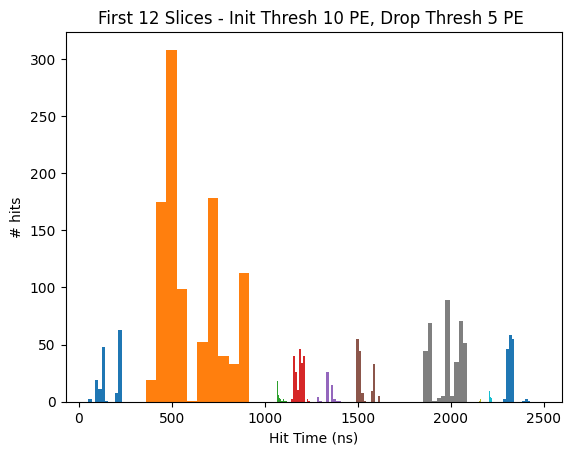

In [8]:
#Here is where we can run the time slicer and then validate:
init_thresh = 10
drop_thresh = 5
sliced = SimpleTimeSlicer(hit_array_merged, initial_threshold_energy = init_thresh, drop_threshold_energy = drop_thresh) #15, 7
put_in_slices, no_in_slices, frac_not_in_slices = ValidateEvents(sliced, hit_array_merged)
TimePlot(sliced, 12, init_thresh, drop_thresh)

In [9]:
def SliceEvaluate(events):
    slice_stack = StackEvents(events)
    containment_array = np.full((5978,5), -1.) #here, I am assigning -1, will tell us if the neutrino event is just never picked up by the slicer. 
    #if we filled with zeroes could mistake for something that was picked up but at very low efficiency %, a different thing!!

    #containment_array = np.zeros((5978,5)) #|nn | hit containment | PE containment | best hit containment slice | best PE containment slice |
    purity_array = np.zeros((len(slice_stack),2))

    for i in range(5978):
        containment_array[i][0] = i

    for j in range(len(slice_stack)):
        slice_number = j
        selected_slice = slice_stack[j]
        nns = selected_slice[:,0] #grab the neutrino numbers
        nns_represented, counts = np.unique(nns, return_counts = True) #counts can be used to determine the hit containment, need to loop for PEs

        #fill purity array
        purity_array[slice_number][0] = slice_number
        purity_array[slice_number][1] = len(nns_represented) #fill our purity array with number of unique neutrino numbers in the slice. 
    
        for i, nn in enumerate(nns_represented):
            total_hits = neutrino_PE_array_merged[int(nn)][2] #total hits
            total_PEs = neutrino_PE_array_merged[int(nn)][1] #total PE
            hits_in_slice = counts[i] #hits in this slice
            filtered_rows = (slice_stack[slice_number][slice_stack[slice_number][:, 0] == nn]) #grab subarray of rows with our hits
            PEs_in_slice = np.sum(filtered_rows[:,6]) #sum all the PEs for this nn in the slice. 
        
            containment_array[int(nn)][0] = nn #neutrino_number
        
            if (containment_array[int(nn)][1]) <= (hits_in_slice / total_hits) :
                containment_array[int(nn)][1] = hits_in_slice / total_hits #hits contained
                containment_array[int(nn)][3] = slice_number

            if (containment_array[int(nn)][2]) <= (PEs_in_slice / total_PEs) :
                containment_array[int(nn)][2] = PEs_in_slice / total_PEs #PEs contained
                containment_array[int(nn)][4] = slice_number #this slice. 

    #Create a masked version of the array
    neutrinos_with_TMS_hits = np.where(neutrino_PE_array_merged[:, 2] != 0)[0] #check that number of hits is non-zero
    masked_containment_array = containment_array[neutrinos_with_TMS_hits]

    #return containment, masked containment, and purity. 
    return(containment_array, masked_containment_array, purity_array)
    

In [30]:
containment_array, masked_containment_array, purity_array = SliceEvaluate(sliced)
# a useful mask to apply is one that looks at the efficiency and purity for neutrino events with TMS hits. 

In [31]:
masked_containment_array

array([[0.00000000e+00, 1.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [2.00000000e+00, 9.60784314e-01, 9.94293499e-01, 0.00000000e+00,
        0.00000000e+00],
       [3.00000000e+00, 1.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       ...,
       [5.97400000e+03, 1.00000000e+00, 1.00000000e+00, 5.85000000e+02,
        5.85000000e+02],
       [5.97500000e+03, 8.21428571e-01, 9.76487459e-01, 5.86000000e+02,
        5.86000000e+02],
       [5.97700000e+03, 9.81481481e-01, 9.99147312e-01, 5.86000000e+02,
        5.86000000e+02]])

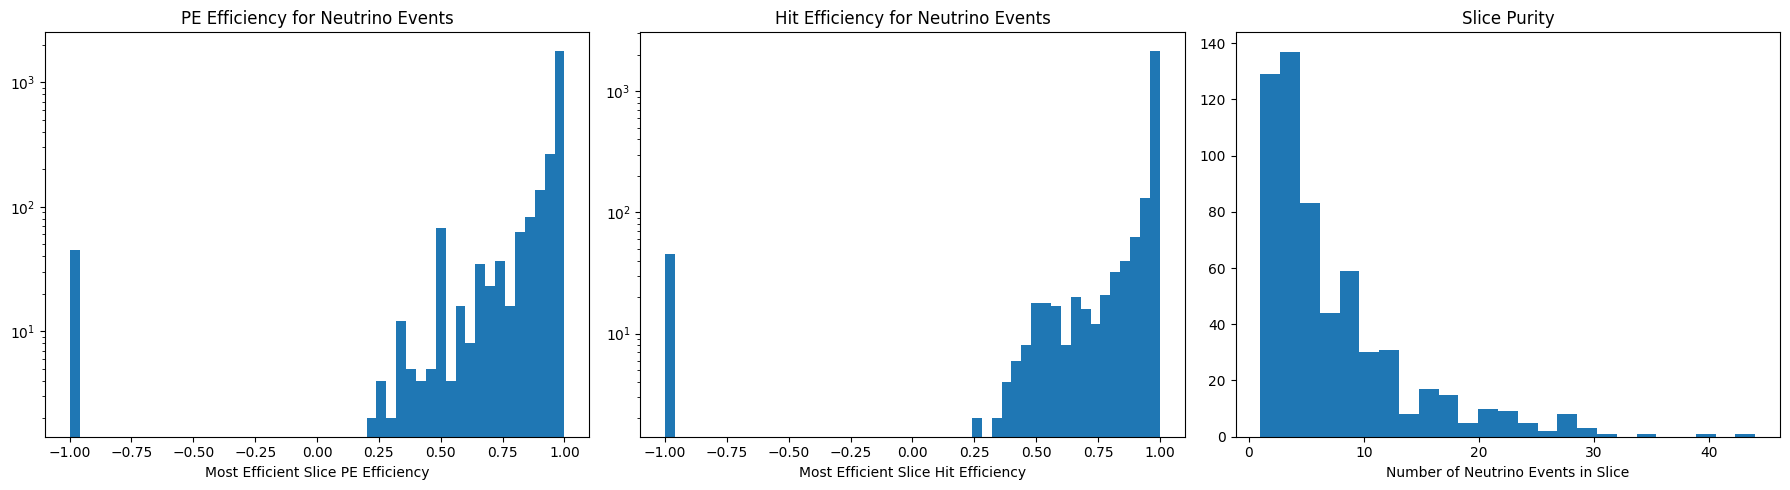

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#Note, a -1 means the neutrino had hits in the TMS, but they weren't picked up. 

# Plot 1: PE Efficiency
axes[0].hist(masked_containment_array[:,1], bins=50)
axes[0].set_title("PE Efficiency for Neutrino Events")
axes[0].set_xlabel("Most Efficient Slice PE Efficiency")
axes[0].set_yscale('log')

# Plot 2: Hit Efficiency
axes[1].hist(masked_containment_array[:,2], bins=50)
axes[1].set_title("Hit Efficiency for Neutrino Events")
axes[1].set_xlabel("Most Efficient Slice Hit Efficiency")
axes[1].set_yscale('log')

# Plot 3: Slice Purity
axes[2].hist(purity_array[:,1], bins=25)
axes[2].set_title("Slice Purity")
axes[2].set_xlabel("Number of Neutrino Events in Slice")

plt.tight_layout()
plt.show()

In [33]:
#The -1 tag allows us to skim the neutrino numbers of 0 efficiency hits for further investigation
unskimmed_neutrino_events = np.where(masked_containment_array[:, 2] == -1)[0] #indexes of events in the masked array... will need to grab neutrino numbers tho
#Lets grab the total hits and PE for these events. 
excluded_PEs = []
excluded_hits = []
for index in unskimmed_neutrino_events:
    neutrino_number = masked_containment_array[index][0]
    PEs = neutrino_PE_array_merged[int(neutrino_number)][1]
    excluded_PEs.append(PEs)
    hits = neutrino_PE_array_merged[int(neutrino_number)][2]
    excluded_hits.append(hits)

skimmed_neutrino_events = np.where(masked_containment_array[:,2] != -1)[0]

included_PEs = []
included_hits = []
for index in skimmed_neutrino_events:
    neutrino_number = masked_containment_array[index][0]
    PEs = neutrino_PE_array_merged[int(neutrino_number)][1]
    included_PEs.append(PEs)
    hits = neutrino_PE_array_merged[int(neutrino_number)][2]
    included_hits.append(hits)

In [35]:
unskimmed_neutrino_events

array([ 105,  109,  191,  205,  248,  258,  266,  309,  416,  430,  545,
        569,  617,  644,  739,  774,  791,  798,  828,  954, 1034, 1125,
       1158, 1168, 1335, 1378, 1407, 1492, 1545, 1576, 1755, 1763, 1766,
       1870, 1972, 1979, 2084, 2112, 2303, 2304, 2339, 2386, 2487, 2539,
       2602])

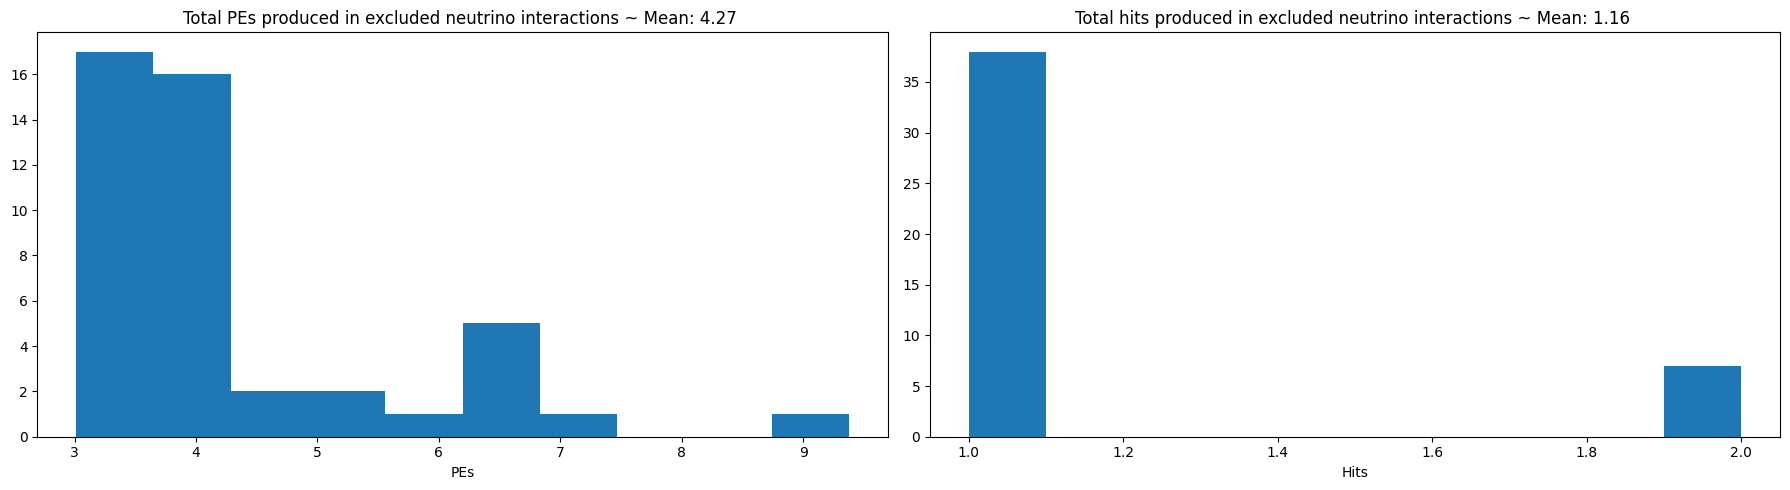

Total Excluded Events 45


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

number_excluded = len(excluded_PEs)
mean_PEs = np.mean(excluded_PEs)
mean_hits = np.mean(excluded_hits)

# Plot 1: Total PE for excluded events
axes[0].hist(excluded_PEs)
axes[0].set_title(f"Total PEs produced in excluded neutrino interactions ~ Mean: {mean_PEs:.2f} ")
axes[0].set_xlabel("PEs")
#axes[0].set_yscale('log')

# Plot 2: Total Hits for excluded events
axes[1].hist(excluded_hits)
axes[1].set_title(f"Total hits produced in excluded neutrino interactions ~ Mean: {mean_hits:.2f} ")
axes[1].set_xlabel("Hits")
#axes[1].set_yscale('log')

plt.tight_layout()
plt.show()
print(f"Total Excluded Events {number_excluded}")


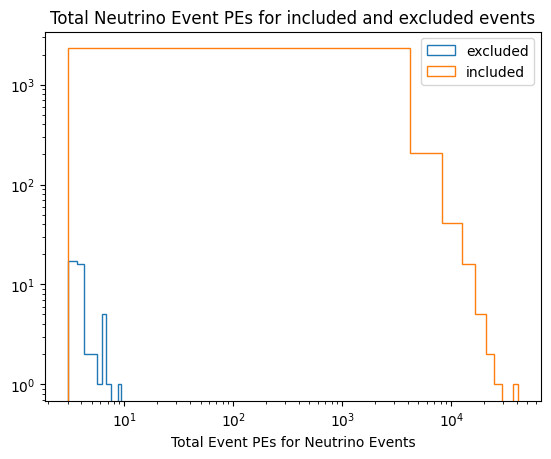

In [21]:
plt.hist(excluded_PEs, histtype = 'step', label = 'excluded')
plt.hist(included_PEs, histtype = 'step', label = 'included')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Event PEs for Neutrino Events')
plt.title('Total Neutrino Event PEs for included and excluded events')
plt.legend()

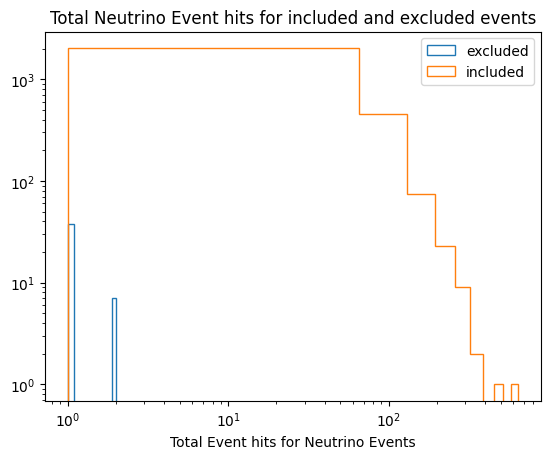

In [16]:
plt.hist(excluded_hits, histtype = 'step', label = 'excluded')
plt.hist(included_hits, histtype = 'step', label = 'included')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Event hits for Neutrino Events')
plt.title('Total Neutrino Event hits for included and excluded events')
plt.legend()

In [17]:
#This script is getting a little unrully but here is a function to grab trajectory information:
f = root.TFile.Open("/sdf/home/t/tanaka/MicroProdN4p1_NDComplex_FHC.spill.full.0002459.EDEPSIM_SPILLS.root")
events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
events.SetBranchAddress("Event",root.AddressOf(event))

4

In [18]:
#sweeps over the trajectories and grabs information for ones which leave trajectory points in the TMS. 
def TrajectorySweeper(events, event_number):
    events.GetEntry(event_number)
    #Let's make sure there are hit segments in the TMS
    tms_hit_segments = event.SegmentDetectors['volTMS']
    if tms_hit_segments.size() > 0:
        #grab the event trajectories vector if we have hits in the TMS, would also be interesting to grab primaries I think, to check for muon. 
        event_primaries = event.Primaries
        event_trajectories = event.Trajectories 
        
        #now loop over each trajectory in the trajectory vector
        trajs_in_tms_info = [] #stores hit info like |x|y|z|t|trackid|parentid|particle type|
        all_trajs = [] #carries an array of trackid and pdgid for all tracks 
        for traj in event_trajectories:
            #each trajectory has a vector of trajectory points. These are tracks of what was traveling through the detector, no edep
            points = traj.Points 
            all_trajs.append(np.array((traj.GetTrackId(),traj.GetPDGCode())))
            #let's make note of the trackids with trajectory positions in the TMS z >= 11185 mm 
            for point in points:
                point_z = point.GetPosition()[2]
                if point_z >= 11185:
                    info_array = np.zeros((1,7))
                    info_array[0][0] = point.GetPosition()[0] #x
                    info_array[0][1] = point.GetPosition()[1] #y
                    info_array[0][2] = point.GetPosition()[2] #z
                    info_array[0][3] = point.GetPosition()[3] #t
                    info_array[0][4] = traj.GetTrackId() #trackID
                    info_array[0][5] = traj.GetParentId() #parentID
                    info_array[0][6] = traj.GetPDGCode() #pdgid of the trajectory that left it!
                    #print(info_array)
                    trajs_in_tms_info.append(info_array)

        info_stack = np.vstack(trajs_in_tms_info)
        all_trajs_stack = np.vstack(all_trajs)
        return((all_trajs_stack, info_stack))#trajs_in_tms_info))

    else:
        #print(f"No energy deposition in TMS for event {event_number}")
        return((None,None))

def hitcolor(pdgid):
    c = 'black' # black track by default
    if pdgid == 2212:
        c = 'red' # proton == red
    if pdgid == 2112:
        c = 'green' # neutron == green
    if pdgid == 211:
        c = 'magenta' # pi+ == magenta
    if pdgid == -211:
        c = 'cyan' # pi- == cyan
    if pdgid == 22:
        c = 'gold' # photon == gold
    if pdgid == 13:
        c = 'purple' #muon
    if pdgid == -13:
        c = 'lightcoral' #anti muon
    """
    if pdgid == 130:
        c = 'orange' # K-long == orange
    if pdgid == 310:
        c = 'darkred' # K-short == dark red
    if pdgid == 321:
        c = 'violet' # K+ == violet
    if pdgid == -321:
        c = 'powderblue' # K- == powder blue

    """
    if pdgid == 11:
        c = 'blue' # electron == blue
    return c    

In [42]:
#Pull neutrino numbers from the unskimmed events
unskimmed_nns = []
for index in unskimmed_neutrino_events:
    neutrino_number = masked_containment_array[index][0]
    unskimmed_nns.append(int(neutrino_number))

print(unskimmed_nns)

[256, 262, 441, 472, 570, 595, 617, 736, 977, 1004, 1259, 1302, 1423, 1492, 1715, 1783, 1817, 1826, 1895, 2174, 2349, 2547, 2640, 2665, 3044, 3147, 3201, 3427, 3548, 3622, 4048, 4064, 4069, 4304, 4517, 4533, 4775, 4830, 5264, 5265, 5355, 5447, 5668, 5782, 5928]


In [46]:
event_tms_trajectory_info = []
#we can run this one the whole set, or a subset of indices returned by the excluded events or something
for i in unskimmed_nns:
    #run the trajectory sweeper
    package = []
    full_trajs , tms_trajpoint_info = TrajectorySweeper(events, i)
    package.append(full_trajs)
    package.append(tms_trajpoint_info)
    event_tms_trajectory_info.append(package)


In [93]:
#a function to scan for Michel electrons in a event.
def MichelScanner(all_trajs, traj_points, neutrino_number):
    #print(traj_points)
    electrons_array = traj_points[traj_points[:,6] == 11]
    for electron in electrons_array:
        electron_parent_id = electron[5]
        matching_parent = all_trajs[all_trajs[:,0] == electron_parent_id ] #may be multiple due to the way that edep saves trajectories
        if matching_parent[0][1] == 13:
            #print(f"Found a Michel electron in neutrino event {neutrino_number}")
            return(neutrino_number)
        #else:
        #    print(f"No Michel electrons in neutrino event {neutrino_number}")
                

MichelScanner(event_tms_trajectory_info[1][0], event_tms_trajectory_info[1][1], 1)

In [94]:
#checking for Michels in unskimmed
for i, nn in enumerate(unskimmed_nns):
    michels = []
    all_trajs = event_tms_trajectory_info[i][0]
    traj_points = event_tms_trajectory_info[i][1]
    michels.append(MichelScanner(all_trajs, traj_points, nn))
    np.unique(michels)


[ 21611.1857889  300000.          21611.1857889  ...  18149.40529577
  18149.17184689  18173.        ]


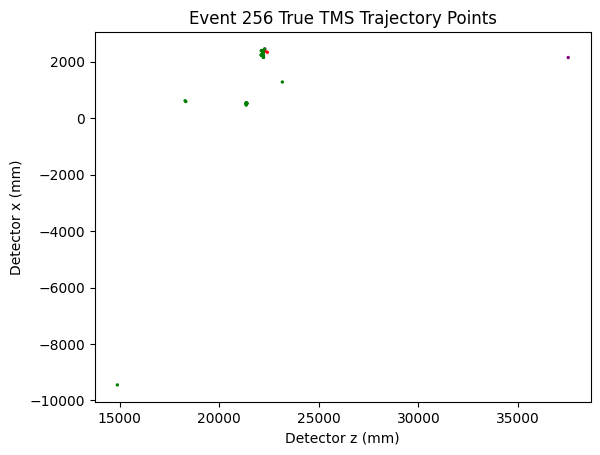

In [90]:
#a basic event display with pdgid coloring
#the index in the unskimmed neutrino events array should match the one in event_tms_trajectory_info
event_ = event_tms_trajectory_info[42]
trajpoint_xs = event_[1][:,0]
print(trajpoint_zs)
trajpoint_zs = event_[1][:,2]
trajpoint_pdgids = event_[1][:,6]
colors = []
for pid in trajpoint_pdgids:
    colors.append(hitcolor(pid))
#Can consult the function for a key of what pdgids match to the colors.
plt.scatter(trajpoint_zs , trajpoint_xs, c = colors, s = 2)
plt.xlabel("Detector z (mm)")
#plt.xlim((11000,18000))
#plt.ylim((-5000,5000))
plt.ylabel("Detector x (mm)")
plt.title(f"Event {neutrino_number} True TMS Trajectory Points")
plt.show()   

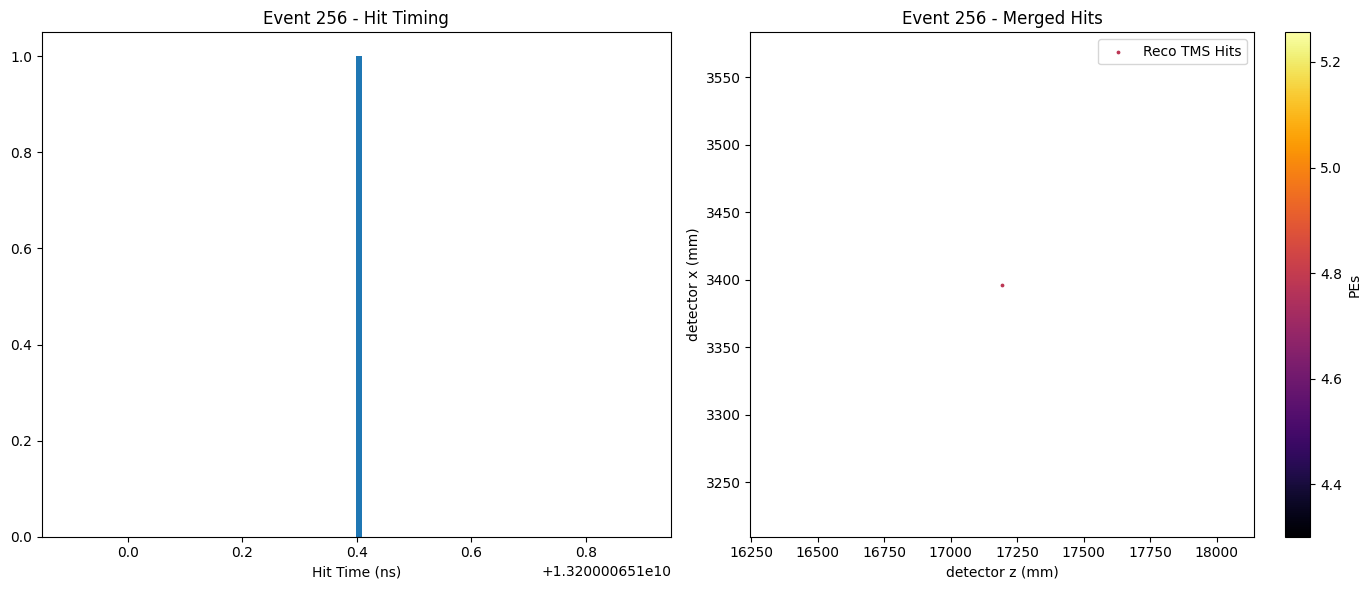

In [91]:
# Reco hit data
reco_hit_xs = []
reco_hit_zs = []
reco_hit_PEs = []
reco_hit_Ts = []

for hit in hit_array_merged:
    if (hit[0] == 5355):
        reco_hit_xs.append(hit[2])
        reco_hit_zs.append(hit[4])
        reco_hit_Ts.append(hit[5])
        reco_hit_PEs.append(hit[6])

#event_neutrino = [vtx for vtx in neutrino_vertices if vtx[0] == event_number_example]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot reco hits
sc2 = ax2.scatter(reco_hit_zs, reco_hit_xs, s=3, c=reco_hit_PEs, cmap='inferno', label='Reco TMS Hits')
#ax2.scatter(event_neutrino[0][3], event_neutrino[0][1], s=35, c='blue', marker='*', label='True Neutrino Vertex')
ax2.set_xlabel("detector z (mm)")
ax2.set_ylabel("detector x (mm)")
ax2.set_title(f"Event {neutrino_number} - Merged Hits")
ax2.legend()
fig.colorbar(sc2, ax=ax2, label='PEs')

# Plot truth hits
sc1 = ax1.hist(reco_hit_Ts, bins=100)
ax1.set_xlabel("Hit Time (ns)")
ax1.set_title(f"Event {neutrino_number} - Hit Timing")

plt.tight_layout()
plt.show()
